<a href="https://colab.research.google.com/github/dcthyun0308/ESAA/blob/main/ESAA_OB_week13_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#13.3 적대적 생성 신경망(GAN)이란
- 생성 모델은 최대한 진짜와 비슷한 데이터를 생성하려는 생성자와 진짜와 가짜를 구별하는 판별자가 각각 존재하여 서로 적대적으로 학습함.

##13.3.1 GAN 동작 원리
- 적대적 생성 신경망은 생성자와 판별자 네트워크 두 개로 구성되어 있음.
- 생성자 G는 판별자 D를 속이려고 원래 이미지와 최대한 비슷한 이미지를 만들도록 학습함. 반대로 판별자 D는 원래 이미지와 생성자 G가 만든 이미지를 잘 구분하도록 학습을 진행함.

##13.3.2 GAN 구현

In [1]:
import imageio # 이미지 데이터를 읽고 쓸 수 있는 쉬운 인터페이스를 제공하는 라이브러리
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pylab as plt

from torchvision.utils import make_grid, save_image
import torchvision.datasets as datasets
import torchvision.transforms as transforms
matplotlib.style.use('ggplot') # 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

필요한 변수에 대한 값을 지정하자.

In [2]:
batch_size = 512
epochs = 200
sample_size = 64 # 1
nz = 128 # 2
k = 1 # 3

예제에서 진행할 MNIST를 내려받아 정규화를 적용하자. 이후에는 데이터로더에 데이터를 전달하여 모델의 학습에 사용할 수 있도록 하자.

In [3]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 23.69 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(), # 이미지를 텐서로 변환
    transforms.Normalize((0.5,),(0.5,)), # 이미지를 평균이 0.5, 표준편차가 0.5가 되도록 정규화
])

train_dataset = datasets.MNIST(
    root = '080289/chap13/data', train = True, transform = transform, download = True)
train_loader = DataLoader(
    train_dataset, batch_size = batch_size, shuffle = True, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


먼저, 생성자 네트워크를 만들어 보자. 간단한 예제를 위해 네 개의 선형 계층과 세 개의 리키렐루 활성화 함수를 사용하자.

In [5]:
class Generator(nn.Module):
  def __init__(self, nz):
    super(Generator, self).__init__()
    self.nz = nz
    self.main = nn.Sequential(
        nn.Linear(self.nz, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 512), nn.LeakyReLU(0.2),
        nn.Linear(512, 1024), nn.LeakyReLU(0.2),
        nn.Linear(1024, 784), nn.Tanh(),
    )

  def forward(self, x):
    return self.main(x).view(-1, 1, 28, 28) # 생성자 네트워크의 반환값은 '배치 크기x1x28x28'이 됩니다.

이제 판별자 네트워크를 생성해 보자. 판별자는 이진 분류자라는 것을 고려하여 신경망을 구축해야 함.

In [6]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.n_input = 784 # 판별자의 입력 크기
    self.main = nn.Sequential(
        nn.Linear(self.n_input, 1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(1024, 512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
        nn.Sigmoid(),
    )
  def forward(self, x):
    x = x.view(-1, 784)
    return self.main(x) # 이미지가 진짜인지 가짜인지를 분류하는 값을 반환

앞에서 생성한 생성자와 판별자 네트워크를 초기화하자. 이때 생성자는 잠재 벡터 nz라는 변수를 파라미터로 전달해야 함.

In [7]:
generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


이제 모델의 네트워크에서 사용할 옵티마이저와 손실 함수를 정의하자. 중요한 것은 생성자와 판별자에서 사용할 옵티마이저를 따로 정의해야 한다는 것.

In [8]:
optim_g = optim.Adam(generator.parameters(), lr = 0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

criterion = nn.BCELoss()

losses_g = [] # 매 에포크마다 발생하는 생성자 오차를 저장하기 위한 리스트형 변수
losses_d = [] # 매 에포크마다 발생하는 판별자 오차를 저장하기 위한 리스트형 변수
images = [] # 생성자에 의해 생성되는 이미지를 저장하기 위한 리스트형 변수

생성자에 의해 만들어지는 새로운 이미지(텐서)를 저장하기 위한 함수를 저장하자. 이 함수는 모델 학습에 반드시 필요한 것은 아니지만 이미지가 생성되는 과정을 이해할 수 있도록 시각화하여 보여 줌.

In [9]:
def save_generator_image(image, path):
  save_image(image, path)

판별자를 학습시키기 위한 함수를 정의하자. 판별자의 학습은 진짜 데이터의 레이블과 가짜 데이터의 레이블을 모두 이용하여 학습함.

In [10]:
def train_discriminator(optimizer, data_real, data_fake):
  b_size = data_real.size(0) # 배치 크기 정보 얻기
  real_label = torch.ones(b_size, 1).to(device) # 1
  fake_label = torch.zeros(b_size, 1).to(device) # 2
  optimizer.zero_grad()
  output_real = discriminator(data_real)
  loss_real = criterion(output_real, real_label) # 진짜 데이터를 판별자에 제공하여 학습한 결과와 진짜 데이터의 레이블을 이용하여 오차를 계산
  output_fake = discriminator(data_fake)
  loss_fake = criterion(output_fake, fake_label) # 가짜 데이터를 판별자에 제공하여 학습한 결과와 가짜 데이터의 레이블을 이용하여 오차를 계산
  loss_real.backward()
  loss_fake.backward()
  optimizer.step()
  return loss_real + loss_fake # 진짜 데이터와 가짜 데이터의 오차가 합쳐진 최종 오차를 반환

이제 생성자 학습을 위한 함수를 정의할 텐데, 상대적으로 판별자의 네트워크보다는 간단함.

In [11]:
def train_generator(optimizer, data_fake):
  b_size = data_fake.size(0)
  real_label = torch.ones(b_size, 1).to(device)
  optimizer.zero_grad()
  output = discriminator(data_fake)
  loss = criterion(output, real_label)
  loss.backward()
  optimizer.step()
  return loss

이제 for 구문을 이용하여 200회 에포크만큼 모델을 학습시키자.

In [12]:
batch_size = 64
epochs = 20

In [14]:
import torchvision
from torchvision.utils import save_image

# 1. 책에서 정의한 이미지 저장 함수 선언
def save_generator_image(image, path):
    save_image(image, path)

In [16]:
generator.train() # 생성자를 학습 모드로 설정
discriminator.train() # 판별자를 학습 모드로 설정

for epoch in range(epochs):
  loss_g = 0.0 # 생성자 오차를 추적(저장)하기 위한 변수
  loss_d = 0.0 # 판별자 오차를 추적(저장)하기 위한 변수
  for idx, data in tqdm(enumerate(train_loader), total=int(len(train_dataset)/train_loader.batch_size)):
    image, _ = data # 학습을 위한 이미지 데이터를 가져옵니다.
    image = image.to(device) # 데이터셋이 CPU/GPU 장치를 사용하도록 지정
    b_size = len(image)
    for step in range(k): # k(1) 스텝 수에 따라 판별자를 실행, 이떄 k 수를 증가시킬 수 있지만 학습 시간이 길어질 수 있으므로 주의
      data_fake = generator(torch.randn(b_size, nz).to(device)).detach() # 1
      data_real = image
      loss_d += train_discriminator(optim_d, data_real, data_fake) # 1'
    data_fake = generator(torch.randn(b_size, nz).to(device))
    loss_g += train_generator(optim_g, data_fake) # 생성자 학습
  generated_img = generator(torch.randn(b_size, nz).to(device)).cpu().detach() # 생성자를 이용하여 새로운 이미지를 생성하고 CPU 장치를 이용하여 디스크에 저장
  generated_img = make_grid(generated_img)
  save_generator_image(generated_img, f"gen_img{epoch}.png")
  epoch_loss_g = loss_g / idx # 에포크에 대한 총 생성자 오차 계산
  epoch_loss_d = loss_d / len(train_loader) # 에포크에 대한 총 판별자 오차 계
  losses_g.append(epoch_loss_g)
  losses_d.append(epoch_loss_d)

  print(f"Epoch {epoch} of {epochs}")
  print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

118it [00:13,  8.88it/s]                         


Epoch 0 of 20
Generator loss: 7.90580225, Discriminator loss: 0.18716770


118it [00:14,  7.96it/s]                         

Epoch 1 of 20
Generator loss: 6.84049177, Discriminator loss: 0.35465053



118it [00:12,  9.40it/s]                         

...

Epoch 17 of 20
Generator loss: 2.68537331, Discriminator loss: 0.48391107



118it [00:12,  9.10it/s]                         

Epoch 18 of 20
Generator loss: 3.14819622, Discriminator loss: 0.53868341



118it [00:13,  8.76it/s]                         

Epoch 19 of 20
Generator loss: 2.95624781, Discriminator loss: 0.53481323


생성자와 판별자의 오차에 대한 변화를 그래프로 살펴보자.

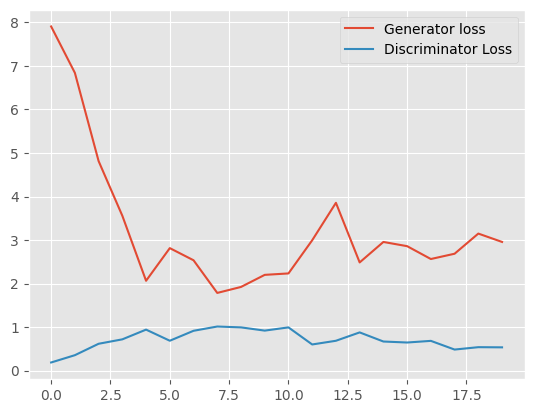

In [17]:
plt.figure()
losses_g = [fl.item() for fl in losses_g]
plt.plot(losses_g, label='Generator loss')
losses_d = [f2.item() for f2 in losses_d]
plt.plot(losses_d, label='Discriminator Loss')
plt.legend()

앞의 이미지를 하나씩 조개서 확인하고 싶다면 다음 코드와 같이 실행하자. 생성된 열 개의 이미지를 보여줌.

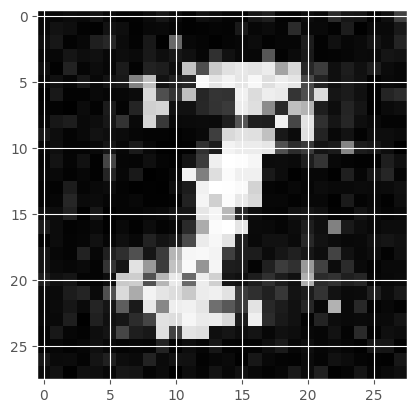

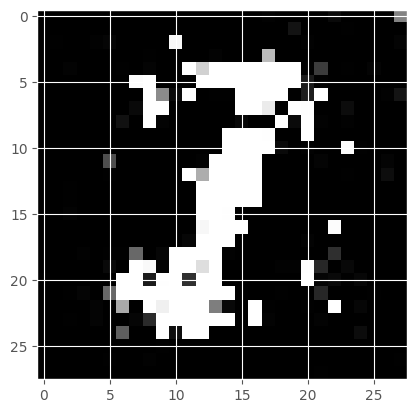

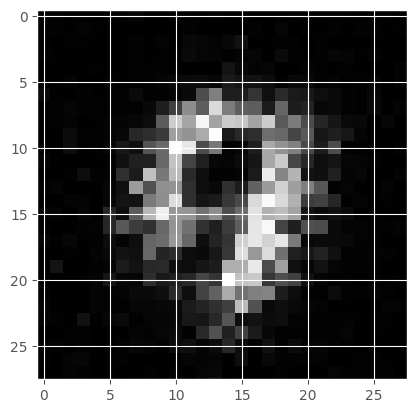

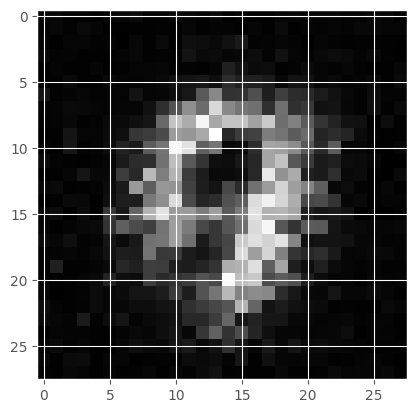

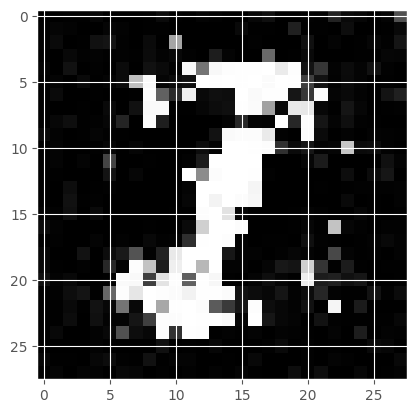

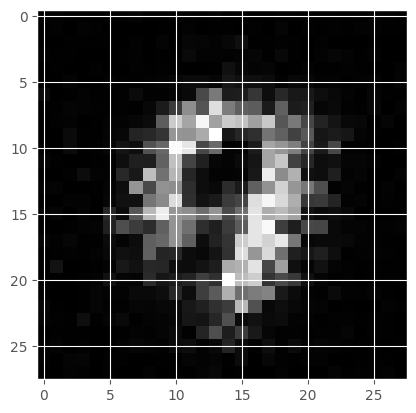

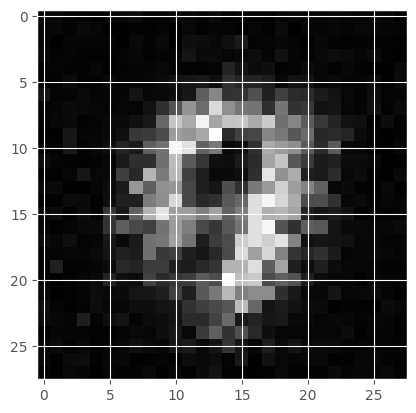

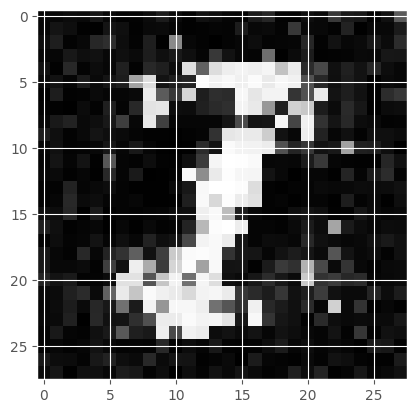

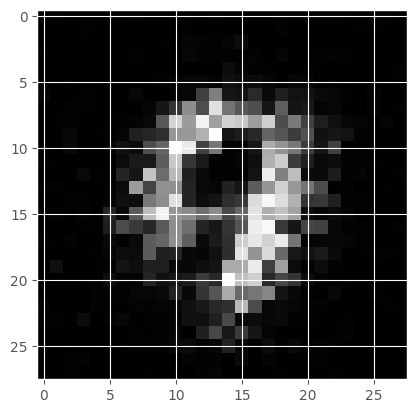

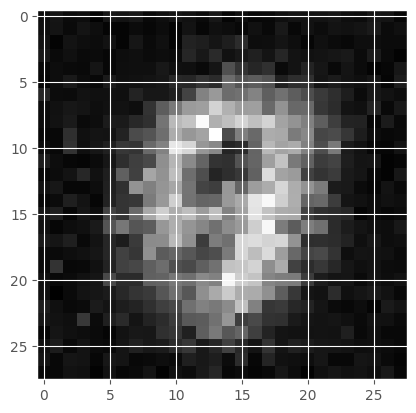

In [22]:
import numpy as np

fake_images = generator(torch.randn(b_size, nz).to(device))
for i in range(10):
  fake_images_img = np.reshape(fake_images.data.cpu().numpy()[i], (28, 28))
  plt.imshow(fake_images_img, cmap='gray')
  plt.savefig('fake_images_img' + str(i) + '.png')
  plt.show()

#13.4 GAN 파생 기술
- GAN은 생성자와 판별자가 서로 대결하면서 학습하는 구조이기 때문에 학습이 매우 불안정. 생성자와 판별자 중 한쪽으로 치우친 훈련이 발생하면 성능에 문제가 생겨 정상적인 분류가 불가능함. 이러한 제약을 해결한 모델이 DCGAN.

##13.4.1 DCGAN
- DCGAN은 GAN과 동일하게 입력된 이미지를 바탕으로 그것과 매우 유사한 가짜 이미지를 만들고, 이를 평가하는 과정을 반복하여 실제와 매우 유사한 이미지를 생산하는 학습법.

### 생성자 네트워크
- 생성자는 임의의 입력을 받아들여 받아들여 판별자에서 사용할 수 있는 이미지 데이터를 생성하며, 출력은 64*64가 됨. 형태가 변경된 입력은 합성곱층으로 넘겨진 후 이미지 형태의 출력을 위해 분수-스트라이드 합성곱을 사용하여 출력 값을 키움.

###판별자 네트워크
- 판별자 네트워크는 64*64 크기의 이미지를 입력받아 진짜 혹은 가짜의 1차원 결과를 출력함. 활성화 함수로 리키렐루를 사용하며, 최종 출력층에는 시그모이드 함수를 사용하여 0~1의 값을 출력함.

##13.4.2 cGAN
-cGAN은 GAN의 출력에 조건을 주어 통제하려는 시도에서 만들어짐. 기본적으로 GAN 원리와 비슷하지만, 생성자와 판별자에 조건을 입력하는 부분에서 차이가 있음. 생성자와 판별자에 조건이 추가되면서 이미지에 대한 변형이 가능하게 됨.

##13.4.3 CycleGAN
- GAN과 DCGAN은 랜덤 노이즈를 입력으로 하므로 무작위 데이터가 생성되기 때문에 원하는 결과를 얻기 어려운 문제가 있음. 이러한 문제를 해결하는 방법으로 PIX2PIX가 있음.

###PIX2PIX
- 임의의 노이즈 벡터가 아닌 이미지를 입력으로 받아 다른 스타일의 이미지를 출력하는 지도 학습 알고리즘

### 생성자 네트워크
- PIX2PIX의 생성자 네트워크는 일반적인 생성자의 구조와 조금 다음. 입력과 출력이 모두 이미지이기 때문에 전체적으로 크기가 줄어들었다가 다시 커지는 인코더-디코더 구조임.

### 판별자 네트워크
- DCGAN과 마찬가지로 스트라이드가 2인 합성곱층으로 구성되어 있음.

###CycleGAN
- PIX2PIX가 강력한 모델이기는 하지만 데이터 쌍이 필요하다는 단점이 있음. 그런데 이러한 데이터 쌍의 이미지를 구하는 것이 쉽지 않은데, 쌍을 이루지 않는 이미지로 학습하기 위해 사용하는 것이 CycleGAN.